# Time-Series Forecasting with SARIMA

**Task 05:** End-to-end daily demand forecasting using trend/seasonality analysis, ADF stationarity testing, SARIMA hyperparameter selection, holdout evaluation with RMSE and MAPE, and a 30-day forecast.

The data contains 30 daily observations. Because the data is daily and the pattern repeats weekly, a seasonal period of 7 is used.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

df = pd.read_csv("daily-demand-series.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").set_index("date")
y = df["demand"].astype(float)
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (30, 3)


,demand,marketing_event,holiday
date,,,
2026-06-01,118,0,0
2026-06-02,121,0,0
2026-06-03,125,0,0
2026-06-04,123,0,0
2026-06-05,137,1,0


## 1. Data Quality and Historical Demand

Missing values:


,missing
demand,0
marketing_event,0
holiday,0


Summary statistics:


,demand,marketing_event,holiday
count,30.000000,30.000000,30.000000
mean,142.100000,0.266667,0.133333
std,13.839848,0.449776,0.345746
min,118.000000,0.000000,0.000000
25%,132.500000,0.000000,0.000000
50%,142.000000,0.000000,0.000000
75%,150.250000,0.750000,0.000000
max,174.000000,1.000000,1.000000


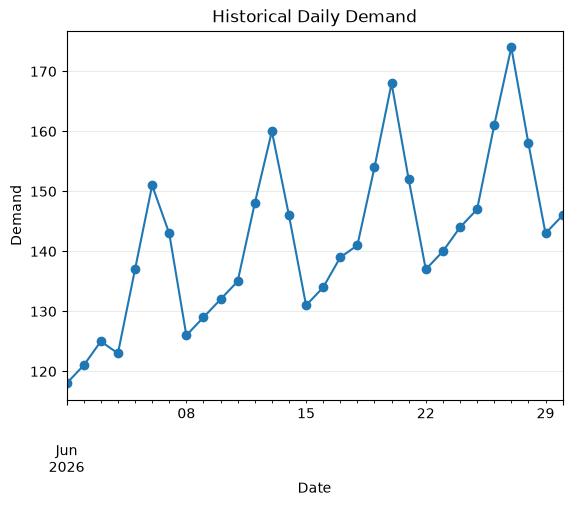

In [2]:
print("Missing values:")
display(df.isna().sum().to_frame("missing"))
print("Summary statistics:")
display(df.describe())
ax=y.plot(marker="o", title="Historical Daily Demand")
ax.set_xlabel("Date"); ax.set_ylabel("Demand"); ax.grid(alpha=.25); plt.show()

## 2. Trend, Seasonality and Residual Decomposition

An additive decomposition with a 7-day period separates the observed demand into trend, seasonal and residual components.

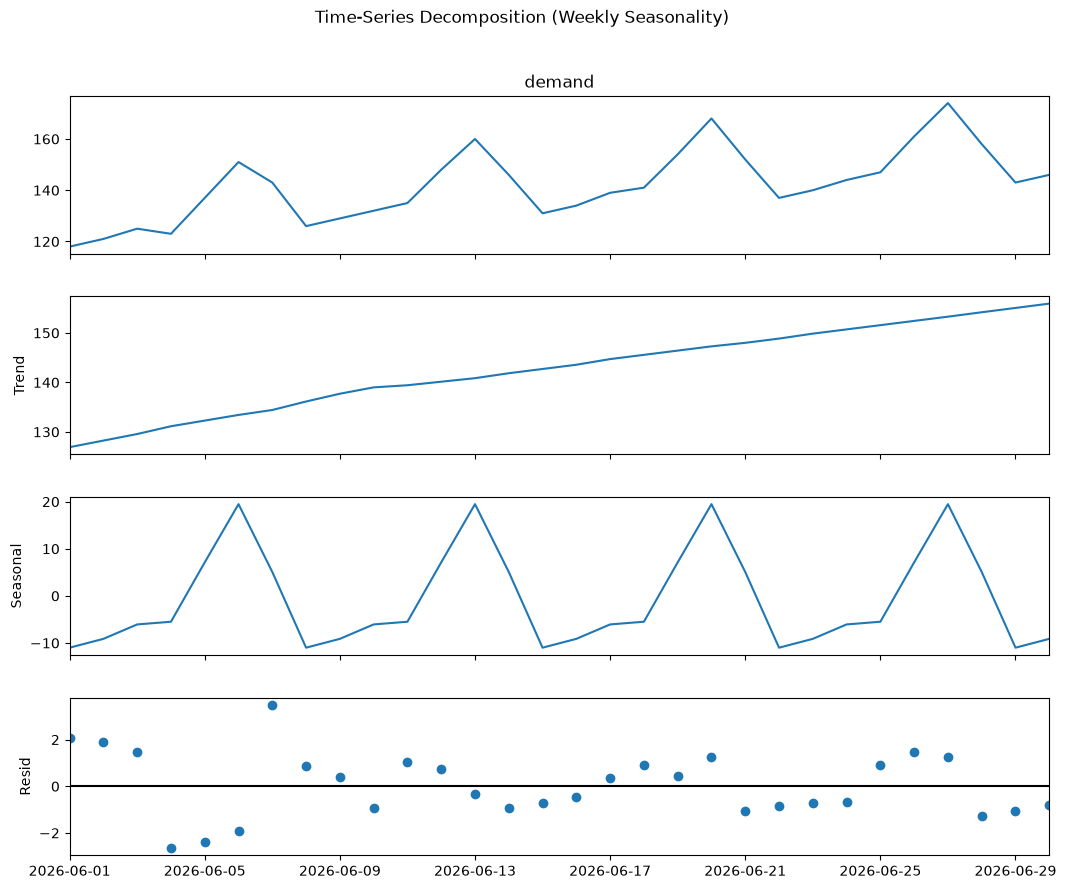

In [3]:
decomp=seasonal_decompose(y,model="additive",period=7,extrapolate_trend="freq")
fig=decomp.plot(); fig.set_size_inches(12,9); plt.suptitle("Time-Series Decomposition (Weekly Seasonality)",y=1.02); plt.show()

## 3. Augmented Dickey-Fuller Stationarity Test

The ADF test is run on the original series and first difference. A p-value below 0.05 is treated as evidence against the unit-root null hypothesis.

In [4]:
def adf_report(s,name):
    r=adfuller(s.dropna(),autolag="AIC")
    return [name,r[0],r[1],r[2],r[3],r[1]<0.05]

adf_table=pd.DataFrame([adf_report(y,"Original"),adf_report(y.diff(),"1st difference"),adf_report(y.diff().diff(),"2nd difference")],columns=["Series","ADF statistic","p-value","Lags","Observations","Stationary at 5%"] )
display(adf_table.round(4))

,Series,ADF statistic,p-value,Lags,Observations,Stationary at 5%
0,Original,-0.9039,0.7867,7,22,False
1,1st difference,-2.2336,0.1943,6,22,False
2,2nd difference,-15.1870,0.0000,5,22,True


### Differencing decision

The ADF results are interpreted together with the visible trend. The original series is clearly non-stationary. The first difference reduces the trend but the ADF p-value remains above 0.05 on this very small sample. SARIMA candidates are therefore evaluated with **d=1**, while seasonal differencing (D=0 or 1) is treated as a model-selection parameter. This avoids claiming that the second difference is stationary when the test does not support that conclusion.

## 4. Chronological Train/Test Split

The final 7 observations are held out as a validation set.

In [5]:
train=y.iloc[:-7]; test=y.iloc[-7:]
print("Training:",train.index.min().date(),"to",train.index.max().date(),"|",len(train),"observations")
print("Test:",test.index.min().date(),"to",test.index.max().date(),"|",len(test),"observations")

Training: 2026-06-01 to 2026-06-23 | 23 observations
Test: 2026-06-24 to 2026-06-30 | 7 observations


## 5. SARIMA Hyperparameter Selection

Candidate non-seasonal and weekly seasonal orders are compared on the chronological holdout. RMSE is the primary selection metric and MAPE is reported alongside it.

In [6]:
def mape(actual,pred):
    actual,pred=np.asarray(actual),np.asarray(pred)
    return np.mean(np.abs((actual-pred)/actual))*100

orders=[(0,1,0),(1,1,0),(0,1,1),(1,1,1),(2,1,0),(0,1,2),(1,1,2),(2,1,1),(2,1,2)]
seasonal_orders=[(0,0,0,7),(1,0,0,7),(0,0,1,7),(1,0,1,7),(0,1,0,7),(1,1,0,7),(0,1,1,7),(1,1,1,7)]
rows=[]
for order in orders:
    for so in seasonal_orders:
        try:
            fit=SARIMAX(train,order=order,seasonal_order=so,enforce_stationarity=False,enforce_invertibility=False).fit(disp=False,maxiter=200)
            pred=fit.forecast(len(test))
            rows.append([order,so,fit.aic,mean_squared_error(test,pred)**0.5,mape(test,pred)])
        except Exception:
            pass
results=pd.DataFrame(rows,columns=["order","seasonal_order","AIC","RMSE","MAPE (%)"]).sort_values(["RMSE","MAPE (%)"]).reset_index(drop=True)
best=results.iloc[0]
display(results.head(10).round(4))
print("Selected SARIMA:",best["order"],"x",best["seasonal_order"])

c:\Users\Asus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Asus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Asus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Asus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Asus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init

,order,seasonal_order,AIC,RMSE,MAPE (%)
0,"(1, 1, 2)","(1, 0, 1, 7)",62.9613,0.4942,0.2445
1,"(0, 1, 0)","(1, 0, 0, 7)",72.3901,0.5195,0.2276
2,"(0, 1, 0)","(1, 0, 1, 7)",70.7959,0.5265,0.2332
3,"(1, 1, 0)","(1, 1, 1, 7)",30.5179,0.5275,0.2099
4,"(1, 1, 0)","(1, 0, 1, 7)",72.3505,0.5282,0.2569
5,"(2, 1, 0)","(0, 1, 0, 7)",66.5157,0.5345,0.1879
6,"(0, 1, 0)","(0, 1, 0, 7)",66.8149,0.5345,0.1879
7,"(1, 1, 0)","(0, 1, 0, 7)",68.4205,0.5345,0.1879
8,"(1, 1, 0)","(1, 1, 0, 7)",28.5208,0.5355,0.1907
9,"(1, 1, 0)","(0, 1, 1, 7)",28.5208,0.5356,0.1907


Selected SARIMA: (1, 1, 2) x (1, 0, 1, 7)


## 6. Holdout Evaluation

c:\Users\Asus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Asus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


,Metric,Value
0,RMSE,0.4942
1,MAPE (%),0.2445


,Actual,Forecast,Absolute Error
2026-06-24,144.0,144.72,0.72
2026-06-25,147.0,147.07,0.07
2026-06-26,161.0,160.18,0.82
2026-06-27,174.0,174.68,0.68
2026-06-28,158.0,158.17,0.17
2026-06-29,143.0,142.89,0.11
2026-06-30,146.0,145.89,0.11


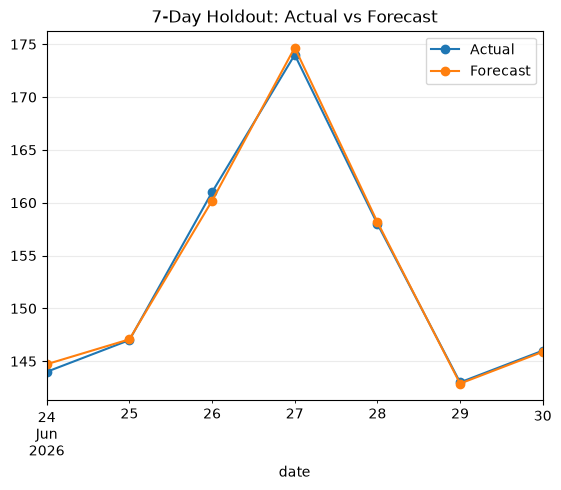

In [7]:
best_order=tuple(best["order"]); best_seasonal=tuple(best["seasonal_order"])
fit=SARIMAX(train,order=best_order,seasonal_order=best_seasonal,enforce_stationarity=False,enforce_invertibility=False).fit(disp=False,maxiter=300)
pred=fit.forecast(len(test))
rmse=mean_squared_error(test,pred)**0.5
mp=mape(test,pred)
metrics=pd.DataFrame({"Metric":["RMSE","MAPE (%)"],"Value":[rmse,mp]})
display(metrics.round(4))
display(pd.DataFrame({"Actual":test,"Forecast":pred,"Absolute Error":abs(test-pred)}).round(2))
ax=test.plot(marker="o",label="Actual"); pred.plot(ax=ax,marker="o",label="Forecast"); ax.set_title("7-Day Holdout: Actual vs Forecast"); ax.legend(); ax.grid(alpha=.25); plt.show()

## 7. Final Model and 30-Day Forecast

The selected SARIMA configuration is refit using all 30 historical observations and used to generate the required 30-day projection.

In [8]:
final=SARIMAX(y,order=best_order,seasonal_order=best_seasonal,enforce_stationarity=False,enforce_invertibility=False).fit(disp=False,maxiter=300)
fr=final.get_forecast(30)
mean=fr.predicted_mean; ci=fr.conf_int()
forecast=pd.DataFrame({"date":mean.index,"forecast_demand":mean.values,"lower_95":ci.iloc[:,0].values,"upper_95":ci.iloc[:,1].values})
display(forecast.round(2))

c:\Users\Asus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Asus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


,date,forecast_demand,lower_95,upper_95
0,2026-07-01,150.18,147.06,153.31
1,2026-07-02,153.36,149.72,156.99
2,2026-07-03,167.38,163.68,171.07
3,2026-07-04,180.25,176.53,183.97
4,2026-07-05,164.34,160.61,168.07
5,2026-07-06,149.42,145.67,153.16
6,2026-07-07,152.40,148.65,156.16
7,2026-07-08,156.58,151.36,161.80
8,2026-07-09,159.75,154.05,165.44
9,2026-07-10,173.69,167.90,179.48


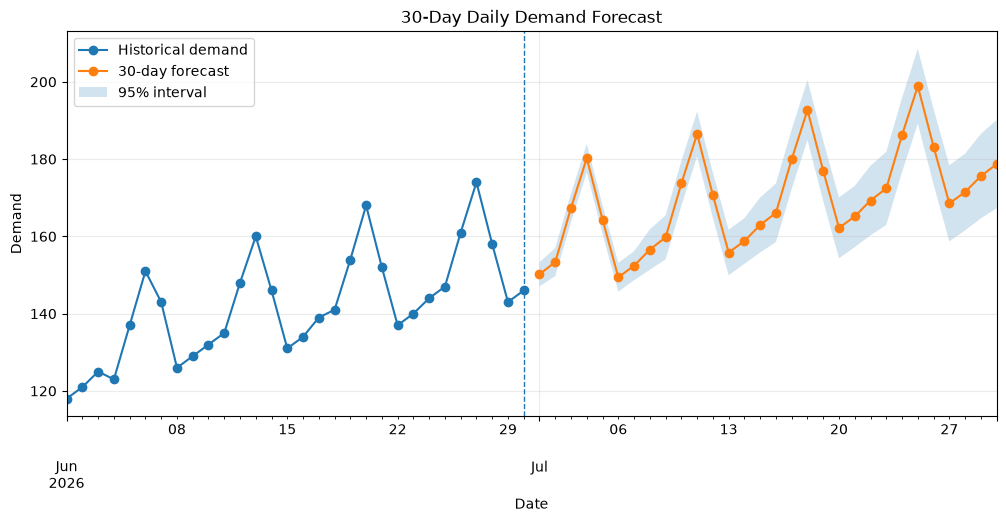

In [ ]:
fig,ax=plt.subplots(figsize=(12,5))
y.plot(ax=ax,marker="o",label="Historical demand")
forecast.set_index("date")["forecast_demand"].plot(ax=ax,marker="o",label="30-day forecast")
x=mdates.date2num(forecast["date"].dt.to_pydatetime())
ax.fill_between(x,forecast["lower_95"].to_numpy(float),forecast["upper_95"].to_numpy(float),alpha=.2,label="95% interval")
ax.xaxis_date(); ax.axvline(y.index[-1],linestyle="--",linewidth=1)
ax.set_title("30-Day Daily Demand Forecast"); ax.set_xlabel("Date"); ax.set_ylabel("Demand"); ax.legend(); ax.grid(alpha=.25); plt.show()

## 8. Findings and Limitations

- The historical series shows an upward trend and a repeating weekly pattern.
- ADF testing does not reject the unit-root null for the original or first-differenced series at the 5% level; the sample is very small, so stationarity conclusions are uncertain.
- SARIMA candidates are compared using a chronological 7-day holdout.
- RMSE and MAPE quantify holdout forecast error.
- The selected model is refit on the full dataset before producing the 30-day forecast.
- The dataset has only 30 observations, so model estimates and forecast intervals should be treated as illustrative rather than production-grade.
- `marketing_event` and `holiday` are not used as future regressors because future values are not provided for the forecast horizon.